# Homework 25: Looking Inside PicoGPT

**Audience.** Students who understand PicoGPT's forward pass and have trained or loaded a small checkpoint.

**Prerequisites.** Transformer blocks, logits and softmax, indexing batched sequences, and basic averages.

**Learning goals.** By the end, you will be able to:

- identify the residual stream at each transformer layer;
- read an attention pattern as a query-by-key matrix;
- apply a simple logit lens to intermediate representations;
- find activation directions associated with a labeled context;
- distinguish correlational inspection from a causal intervention.

This notebook uses an explicit activation cache returned by `forward`. It avoids opaque hooks and makes every inspected tensor visible in the model code.


## Outline

1. Load the fast reference model
2. Inspect the activation cache
3. Visualize one attention pattern
4. Use a logit lens
5. Construct and test a “before a period” direction
6. Notebook checkpoints


In [1]:
# S1: Imports, module path, and deterministic model loading
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

if Path("pico_gpt.py").exists():
    COURSE_DIRECTORY = Path(".")
elif Path("Homework2026/pico_gpt.py").exists():
    COURSE_DIRECTORY = Path("Homework2026")
else:
    raise FileNotFoundError("Place pico_gpt.py beside this notebook.")
sys.path.insert(0, str(COURSE_DIRECTORY.resolve()))

from pico_gpt import (
    build_token_stream,
    get_batch,
    load_checkpoint,
    make_demo_stories,
    split_stories,
)

tiny_reference_path = COURSE_DIRECTORY / "pico_gpt_tinystories_reference.pt"
fast_reference_path = COURSE_DIRECTORY / "pico_gpt_reference.pt"
checkpoint_path = (
    tiny_reference_path if tiny_reference_path.exists() else fast_reference_path
)
if not checkpoint_path.exists():
    raise FileNotFoundError(
        "The immutable course reference checkpoint is missing."
    )

model, tokenizer, metadata = load_checkpoint(checkpoint_path)
source = checkpoint_path.name

model.eval()
print("model source:", source)
print("layers:", model.config.n_layers, "width:", model.config.d_model)


model source: pico_gpt_reference.pt
layers: 2 width: 64


In [2]:
# S2: Reconstruct the validation stream and take a fixed batch
stories = make_demo_stories()
train_stories, validation_stories = split_stories(stories)
validation_stream = build_token_stream(validation_stories, tokenizer)
target_layer = max(0, model.config.n_layers - 2)

generator = torch.Generator().manual_seed(250)
inputs, targets = get_batch(
    validation_stream,
    batch_size=8,
    block_size=model.config.block_size,
    generator=generator,
)

with torch.no_grad():
    logits, loss, cache = model(inputs, targets, return_cache=True)

print("validation loss:", round(float(loss), 3))
print("cache keys:", list(cache.keys()))
print("number of block caches:", len(cache["blocks"]))


validation loss: 0.629
cache keys: ['token_embeddings', 'position_embeddings', 'embedding_stream', 'blocks', 'normalized']
number of block caches: 2


## 1. The residual stream

The residual stream is the `d_model`-dimensional vector carried at every token position. Attention and the MLP read from it and add updates to it. The cache records the stream before attention, between attention and the MLP, and after the MLP.


In [3]:
# S3: Inspect every tensor cached for one block
for layer_index, block_cache in enumerate(cache["blocks"]):
    print(f"layer {layer_index}")
    for name, tensor in block_cache.items():
        print(f"  {name:22s} {tuple(tensor.shape)}")


layer 0
  residual_pre           (8, 48, 64)
  attention_weights      (8, 4, 48, 48)
  attention_output       (8, 48, 64)
  residual_mid           (8, 48, 64)
  mlp_hidden             (8, 48, 256)
  mlp_output             (8, 48, 64)
  residual_post          (8, 48, 64)
layer 1
  residual_pre           (8, 48, 64)
  attention_weights      (8, 4, 48, 48)
  attention_output       (8, 48, 64)
  residual_mid           (8, 48, 64)
  mlp_hidden             (8, 48, 256)
  mlp_output             (8, 48, 64)
  residual_post          (8, 48, 64)


The attention pattern has shape `(batch, heads, query positions, key positions)`. All other cached block tensors preserve `(batch, sequence, channels)`, except the MLP's expanded hidden layer.


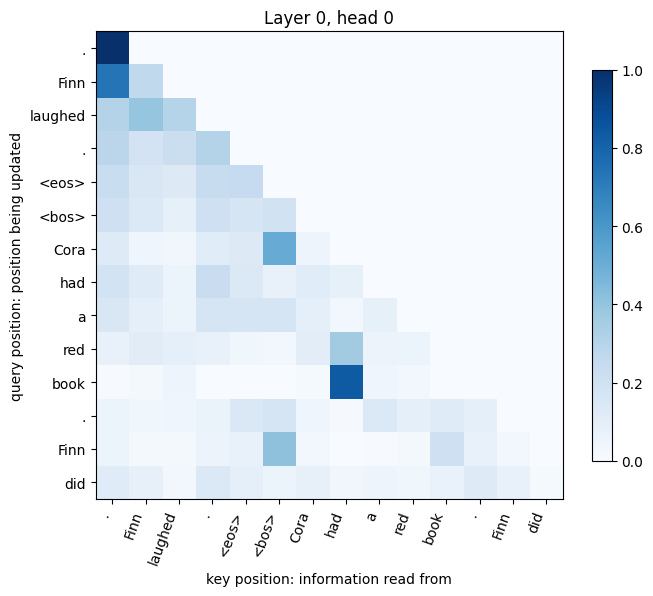

In [4]:
# S4: Visualize one head for the first 14 positions
shown = 14
shown_tokens = [tokenizer.itos[int(index)] for index in inputs[0, :shown]]
pattern = cache["blocks"][0]["attention_weights"][0, 0, :shown, :shown]

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(pattern, cmap="Blues", vmin=0)
ax.set_xticks(range(shown), shown_tokens, rotation=70, ha="right")
ax.set_yticks(range(shown), shown_tokens)
ax.set_xlabel("key position: information read from")
ax.set_ylabel("query position: position being updated")
ax.set_title("Layer 0, head 0")
fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


## 2. A simple logit lens

The actual language-model head is applied only after the final block. As a diagnostic, we can apply the same final normalization and head to earlier residual streams. This asks: “If the model stopped here, which next token would this representation favor?”

This is useful but imperfect—the intermediate layers were not explicitly trained to be decoded this way.


In [5]:
# S5: Decode the final position after each stage
residual_stages = [("embeddings", cache["embedding_stream"])]
residual_stages += [
    (f"after block {index}", block_cache["residual_post"])
    for index, block_cache in enumerate(cache["blocks"])
]

logit_lens_predictions = []
with torch.no_grad():
    for label, residual in residual_stages:
        stage_logits = model.lm_head(model.final_layer_norm(residual))
        predicted_id = int(stage_logits[0, -1].argmax())
        predicted_token = tokenizer.itos[predicted_id]
        logit_lens_predictions.append((label, predicted_token))

logit_lens_predictions


[('embeddings', '.'), ('after block 0', 'The'), ('after block 1', 'The')]

## 3. A labeled activation direction

Before training an SAE, we can make a simple contrastive direction. The target tensor tells us exactly which positions are immediately before a period: those are positions where the next-token target is `.`.

We subtract the mean residual vector at all other positions from the mean vector before periods. This direction is associated with the label, but association alone does not prove causal function.


In [6]:
# S6: Contrast residual activations before periods with other positions
period_id = tokenizer.stoi["."]
hidden = cache["blocks"][target_layer]["residual_post"]
before_period = targets == period_id

period_mean = hidden[before_period].mean(dim=0)
other_mean = hidden[~before_period].mean(dim=0)
period_direction = period_mean - other_mean
period_direction = period_direction / period_direction.norm()

strongest_coordinate = int(period_direction.argmax())
signed_coordinate_value = float(period_direction[strongest_coordinate])

print("before-period positions:", int(before_period.sum()))
print("direction shape:", tuple(period_direction.shape))
print("largest positive coordinate:", strongest_coordinate)
print("signed value there:", round(signed_coordinate_value, 4))


before-period positions: 52
direction shape: (64,)
largest positive coordinate: 48
signed value there: 0.2853


In [7]:
# S7: Rank contexts by projection onto the complete direction
direction_scores = (hidden @ period_direction).reshape(-1)
top_flat_indices = torch.topk(direction_scores, k=6).indices

top_contexts = []
sequence_length = inputs.shape[1]
for flat_index in top_flat_indices:
    row = int(flat_index) // sequence_length
    position = int(flat_index) % sequence_length
    start = max(0, position - 5)
    context_ids = inputs[row, start : position + 1]
    next_token = tokenizer.itos[int(targets[row, position])]
    top_contexts.append(
        f"{tokenizer.decode(context_ids)}  →  next token: {next_token}"
    )

for rank, context in enumerate(top_contexts, start=1):
    print(f"{rank}. ...{context}")


1. ...Rain fell over the garden  →  next token: .
2. ...Rain fell over the garden  →  next token: .
3. ...a red kite near the hill  →  next token: .
4. ...a purple map near the hill  →  next token: .
5. ...Ella wanted to visit the farm  →  next token: .
6. .... They played beside the hill  →  next token: .


## 4. Correlation becomes a causal question

We add the direction after an intermediate transformer block. The edited residual then passes through at least one later block before reaching the language-model head. The model's `intervention` argument makes the edit explicit.


In [8]:
# S8: Add the direction and measure a fixed prompt
candidate_prompts = [
    "Ava found a blue kite",
    "Ava found a blue kite near",
    "Ava found a blue kite near the forest",
    "The path was",
    "Soon they were",
]

candidate_probabilities = []
candidate_tensors = []
with torch.no_grad():
    for candidate in candidate_prompts:
        ids = [tokenizer.bos_id] + tokenizer.encode(
            candidate, add_special_tokens=False
        )
        tensor = torch.tensor([ids])
        candidate_tensors.append(tensor)
        candidate_logits, _ = model(tensor)
        probability = torch.softmax(
            candidate_logits[0, -1], dim=-1
        )[period_id]
        candidate_probabilities.append(float(probability))

# Avoid a ceiling-saturated prompt by choosing P(period) nearest 0.5.
prompt_index = min(
    range(len(candidate_prompts)),
    key=lambda index: abs(candidate_probabilities[index] - 0.5),
)
prompt_text = candidate_prompts[prompt_index]
prompt = candidate_tensors[prompt_index]

def add_period_direction(layer_index, residual):
    if layer_index == target_layer:
        return residual + 2.0 * period_direction
    return residual

with torch.no_grad():
    baseline_logits, _ = model(prompt)
    intervened_logits, _ = model(prompt, intervention=add_period_direction)
    baseline_period_probability = torch.softmax(
        baseline_logits[0, -1], dim=-1
    )[period_id]
    intervened_period_probability = torch.softmax(
        intervened_logits[0, -1], dim=-1
    )[period_id]

print("baseline P(period):", round(float(baseline_period_probability), 4))
print("after intervention:", round(float(intervened_period_probability), 4))
print("change:", round(float(intervened_period_probability - baseline_period_probability), 4))
print("selected prompt:", prompt_text)


baseline P(period): 0.0308
after intervention: 0.6501
change: 0.6193
selected prompt: Ava found a blue kite


A direction constructed from correlation is not guaranteed to raise the period probability for every prompt. Whatever the sign of this result, the intervention turns a vague interpretation into a measurable causal hypothesis.


## Notebook checkpoints


In [9]:
# S9: Deterministic checkpoint record
inspected_cache = cache["blocks"][target_layer]
checkpoint_25 = {
    "reference_checkpoint": checkpoint_path.name,
    "cache_keys": list(cache.keys()),
    "number_of_blocks": len(cache["blocks"]),
    "target_layer": target_layer,
    "residual_post_shape": tuple(inspected_cache["residual_post"].shape),
    "attention_weight_shape": tuple(inspected_cache["attention_weights"].shape),
    "mlp_hidden_width": inspected_cache["mlp_hidden"].shape[-1],
    "period_direction_shape": tuple(period_direction.shape),
    "strongest_coordinate": strongest_coordinate,
    "top_contexts": top_contexts,
    "baseline_period_probability": round(float(baseline_period_probability), 6),
    "intervened_period_probability": round(float(intervened_period_probability), 6),
}
checkpoint_25


{'reference_checkpoint': 'pico_gpt_reference.pt',
 'cache_keys': ['token_embeddings',
  'position_embeddings',
  'embedding_stream',
  'blocks',
  'normalized'],
 'number_of_blocks': 2,
 'target_layer': 0,
 'residual_post_shape': (8, 48, 64),
 'attention_weight_shape': (8, 4, 48, 48),
 'mlp_hidden_width': 256,
 'period_direction_shape': (64,),
 'strongest_coordinate': 48,
 'top_contexts': ['Rain fell over the garden  →  next token: .',
  'Rain fell over the garden  →  next token: .',
  'a red kite near the hill  →  next token: .',
  'a purple map near the hill  →  next token: .',
  'Ella wanted to visit the farm  →  next token: .',
  '. They played beside the hill  →  next token: .'],
 'baseline_period_probability': 0.030804,
 'intervened_period_probability': 0.650131}

## Pitfall and extension

**Pitfall.** A coordinate that is large before periods is not automatically “the period neuron.” It might track story position, proper names, or some correlated template feature.

**Optional extension.** Repeat S6 for quotation marks or `<eos>`, then evaluate the direction on a separate held-out batch. The next homework replaces individual coordinates with sparse learned feature directions.
